# Machine Learning Lab DSC311-4
## Lab Test 3

In [1]:
#Neekitasingh Rajput
#2441339

In [13]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, silhouette_score

Q1) EDA
1. Print dataset shape + column names
2. Check data types
3. Missing values check
4. Show summary statistics

In [14]:
#import dataset

from sklearn.datasets import load_iris
data = load_iris()

df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
#obs: we have taken the sklearn inbuilt iris dataset.

In [16]:
#print dataset shape + column names

print("Dataset Shape:", df.shape)
print("Column names:", df.columns.tolist())

Dataset Shape: (150, 5)
Column names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']


In [17]:
#check data types

df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int32
dtype: object

In [18]:
#missing value check

df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [19]:
#summary statistics

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Q2) Preprocessing 
1. Separate features X
2. Standardize using StandardScaler
3. Print shape of processed X

In [20]:
#seperate features X
X = df.drop("target", axis=1)
y = df['target']

#Standardize using Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
#shape of processed X
print("Processed X shape", X_scaled.shape)

Processed X shape (150, 4)


Q3) K-Means Clustering
1. Apply KMeans for a range of k values (2 to 10)
2. Use random_state=42

Q4) Evaluation (WSS + Silhouette)
1. Compute WSS (inertia) for k=2..10
2. Compute Silhouette Score for k=2..10
3. Plot Elbow Curve + Silhouette Plot
4. Choose best k and justify

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
from sklearn.cluster import KMeans

# Apply KMeans for k=2 to 10
k_values = range(2, 11)
wss = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    wss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

In [28]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    print("K =", k, "\n Silhouette Score =", silhouette_score(X_scaled, labels))

K = 2 
 Silhouette Score = 0.5817500491982808
K = 3 
 Silhouette Score = 0.45994823920518635
K = 4 
 Silhouette Score = 0.38694104154427816
K = 5 
 Silhouette Score = 0.34194697093163473
K = 6 
 Silhouette Score = 0.32674451109112396
K = 7 
 Silhouette Score = 0.32413601115437884
K = 8 
 Silhouette Score = 0.3328739067356281
K = 9 
 Silhouette Score = 0.3561629819248505
K = 10 
 Silhouette Score = 0.3599558463589517


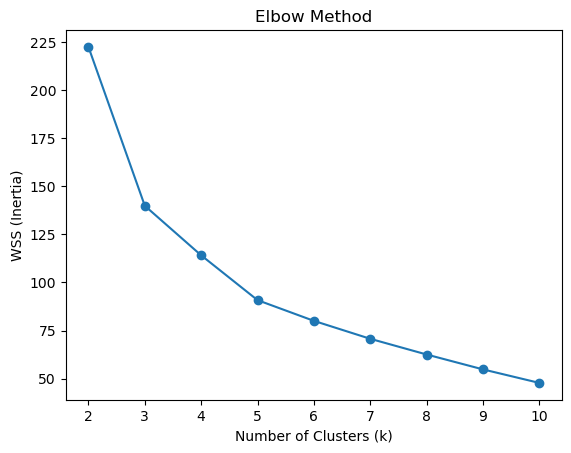

In [29]:
plt.figure()
plt.plot(k_values, wss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WSS (Inertia)")
plt.show()

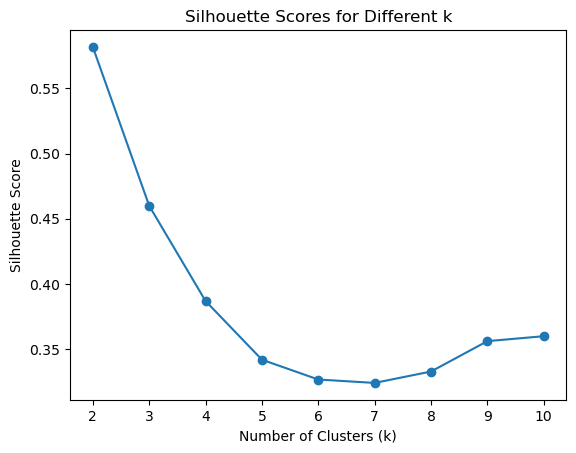

In [30]:
plt.figure()
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

Q5) Conclusion.

The optimal number of clusters is k = 3.
The Elbow method shows a clear bend at k=3, indicating reduced improvement beyond this point.
The Silhouette score is highest near k=3, showing better cluster separation and cohesion.
Since the Iris dataset contains three natural classes, the clustering result aligns well with the dataset structure.